In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA, KernelPCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_breast_cancer, make_blobs, make_circles, load_iris
from sklearn.model_selection import train_test_split

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

1. Попробуйте изменить уровень шума в данных (например, увеличить или уменьшить шум в y) и посмотрите, как это влияет на результат PCA.

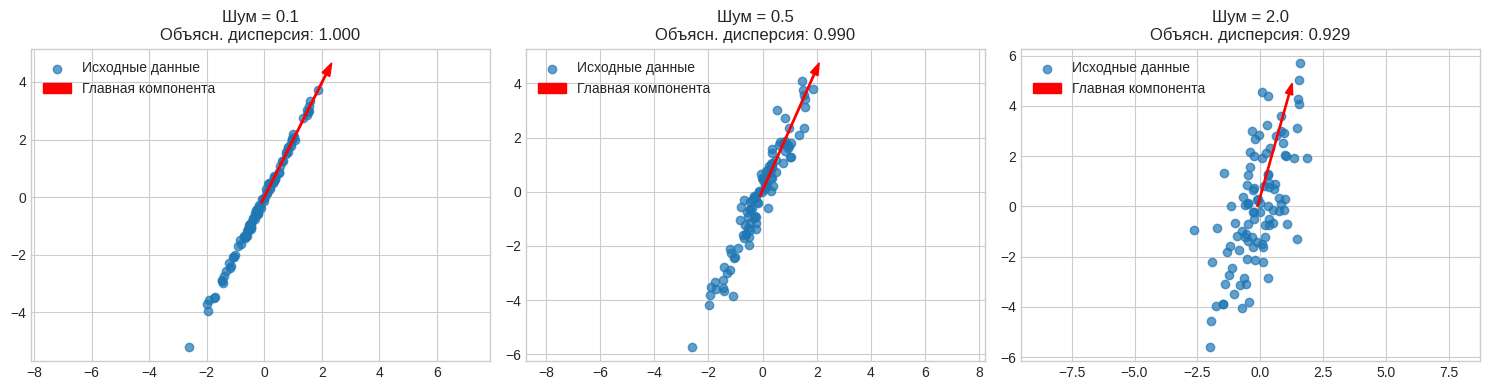

In [ ]:
np.random.seed(42)
n_samples = 100
x = np.random.normal(0, 1, n_samples)

# Разные уровни шума
noise_levels = [0.1, 0.5, 2.0]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, noise in enumerate(noise_levels):
    y = 2 * x + np.random.normal(0, noise, n_samples)
    X = np.column_stack((x, y))

    pca = PCA(n_components=1)
    X_pca = pca.fit_transform(X)

    axes[idx].scatter(X[:, 0], X[:, 1], alpha=0.7, label='Исходные данные')

    # Визуализация главной компоненты
    mean = np.mean(X, axis=0)
    direction = pca.components_[0] * pca.explained_variance_ratio_[0] * 5
    axes[idx].arrow(mean[0], mean[1], direction[0], direction[1],
                    color='red', width=0.05, head_width=0.3, label='Главная компонента')

    axes[idx].set_title(f'Шум = {noise}\nОбъясн. дисперсия: {pca.explained_variance_ratio_[0]:.3f}')
    axes[idx].legend()
    axes[idx].axis('equal')

plt.tight_layout()
plt.show()

С увеличением шума доля объясненной дисперсии падает, направление главной компоненты отклоняется от идеального

2. Добавьте третий признак, который также коррелирует с первыми двумя, и примените PCA с n_components=2.

Форма исходных данных: (200, 3)
Форма после PCA: (200, 2)
Объясненная дисперсия компонент: [0.67958963 0.31604171]
Суммарная объясненная дисперсия: 0.996


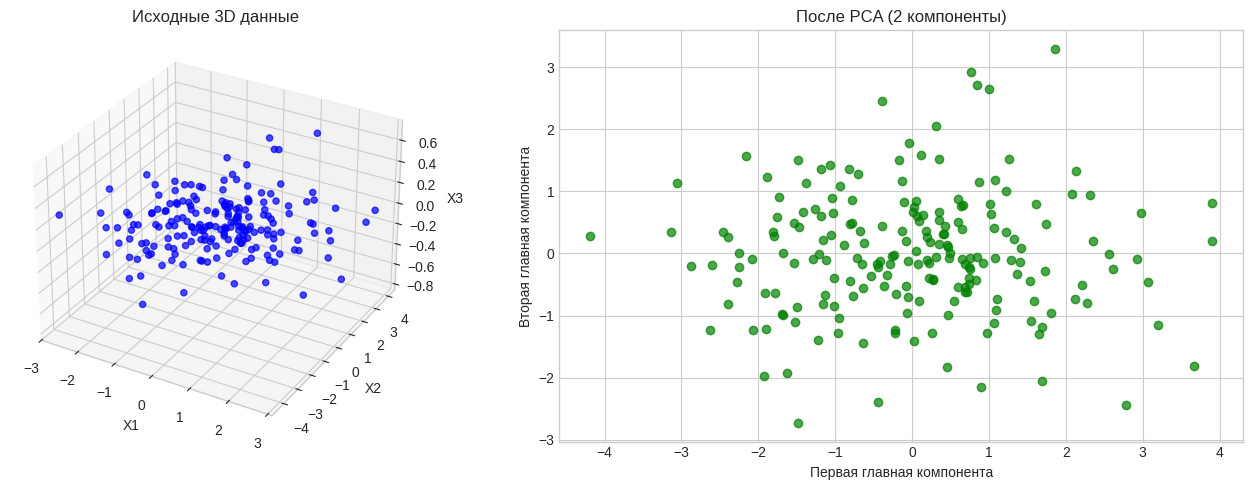

In [ ]:
np.random.seed(42)
n_samples = 200
x1 = np.random.normal(0, 1, n_samples)
x2 = 1.5 * x1 + np.random.normal(0, 0.3, n_samples)
x3 = -0.8 * x1 + 0.5 * x2 + np.random.normal(0, 0.2, n_samples)

X_3d = np.column_stack((x1, x2, x3))

scaler = StandardScaler()
X_scaled_3d = scaler.fit_transform(X_3d)

pca = PCA(n_components=2)
X_pca_3d = pca.fit_transform(X_scaled_3d)

print(f"Форма исходных данных: {X_3d.shape}")
print(f"Форма после PCA: {X_pca_3d.shape}")
print(f"Объясненная дисперсия компонент: {pca.explained_variance_ratio_}")
print(f"Суммарная объясненная дисперсия: {sum(pca.explained_variance_ratio_):.3f}")

# Визуализация
fig = plt.figure(figsize=(14, 5))

ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(x1, x2, x3, alpha=0.7, c='blue')
ax1.set_xlabel('X1')
ax1.set_ylabel('X2')
ax1.set_zlabel('X3')
ax1.set_title('Исходные 3D данные')

ax2 = fig.add_subplot(122)
ax2.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1], alpha=0.7, c='green')
ax2.set_xlabel('Первая главная компонента')
ax2.set_ylabel('Вторая главная компонента')
ax2.set_title('После PCA (2 компоненты)')
ax2.grid(True)

plt.tight_layout()
plt.show()

3. Попробуйте изменить расположение классов (например, сделать их ближе друг к другу) и посмотрите, как это влияет на результат LDA.

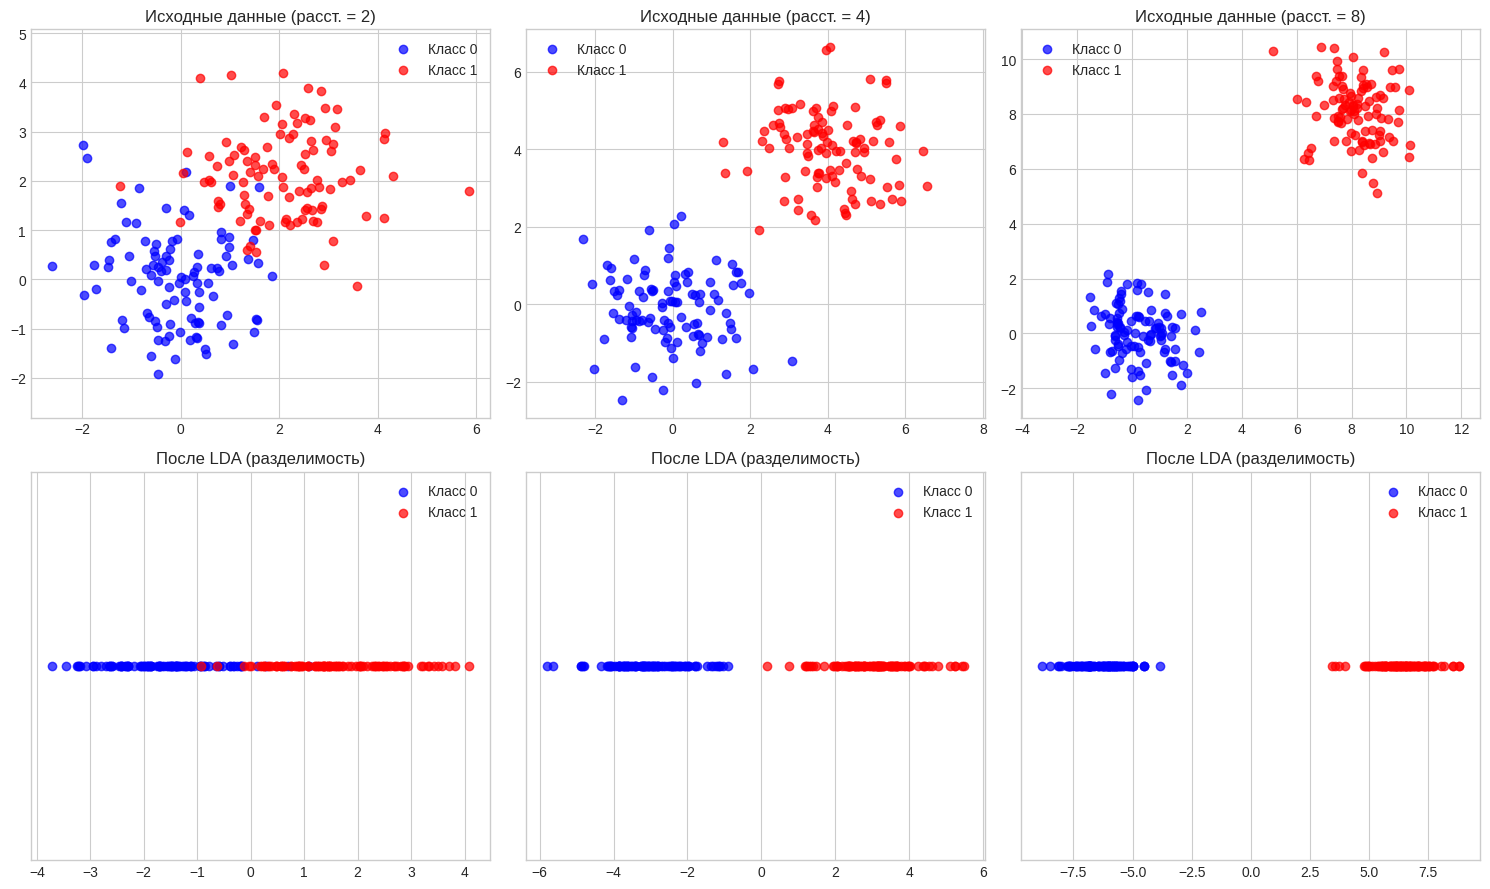

In [ ]:
np.random.seed(42)
n_samples = 100

# Разные расстояния между центрами классов
distances = [2, 4, 8]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for idx, dist in enumerate(distances):
    # Класс 0 в (0,0), класс 1 в (dist, dist)
    x1 = np.random.normal(0, 1, n_samples)
    y1 = np.random.normal(0, 1, n_samples)
    x2 = np.random.normal(dist, 1, n_samples)
    y2 = np.random.normal(dist, 1, n_samples)

    X = np.vstack((np.column_stack((x1, y1)), np.column_stack((x2, y2))))
    y = np.hstack((np.zeros(n_samples), np.ones(n_samples)))

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    lda = LDA(n_components=1)
    X_lda = lda.fit_transform(X_scaled, y)

    # Исходные данные
    axes[0, idx].scatter(X[:n_samples, 0], X[:n_samples, 1], alpha=0.7, label='Класс 0', c='blue')
    axes[0, idx].scatter(X[n_samples:, 0], X[n_samples:, 1], alpha=0.7, label='Класс 1', c='red')
    axes[0, idx].set_title(f'Исходные данные (расст. = {dist})')
    axes[0, idx].legend()
    axes[0, idx].axis('equal')

    # После LDA
    axes[1, idx].scatter(X_lda[y==0], np.zeros_like(X_lda[y==0]), alpha=0.7, c='blue', label='Класс 0')
    axes[1, idx].scatter(X_lda[y==1], np.zeros_like(X_lda[y==1]), alpha=0.7, c='red', label='Класс 1')
    axes[1, idx].set_title(f'После LDA (разделимость)')
    axes[1, idx].set_yticks([])
    axes[1, idx].legend()
    axes[1, idx].grid(True)

plt.tight_layout()
plt.show()

Чем дальше расположены классы, тем легче LDA их разделяет. При малом расстоянии классы могут перекрываться.